<a href="https://colab.research.google.com/github/Omar-Rashdan20/DPO-Fine-Tuning/blob/main/DPO_Fine_Tuning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DPO Fine-Tuning with LLaMA-3, QLoRA, and TRL

## Direct Preference Optimization

---

### What this notebook does

This notebook trains a **LLaMA-3** language model using **Direct Preference Optimization (DPO)** — the state-of-the-art method for aligning large language models with human preferences without requiring a separately trained reward model.

To fit on a single 16 GB T4 GPU, we combine:
- **4-bit quantization (QLoRA)** — base model weights stored in NF4 format
- **LoRA adapters** — only ~0.5% of parameters are trained
- **Paged AdamW 8-bit** — memory-efficient optimizer

### Why DPO instead of PPO?

Traditional RLHF (Reinforcement Learning from Human Feedback) requires:
1. A separately trained **reward model**
2. An **online RL loop** (PPO) that is slow and unstable
3. Careful KL-penalty tuning to prevent policy collapse

**DPO** eliminates all of this. It re-parameterises the optimal RLHF policy in closed form and reduces alignment to a single supervised binary cross-entropy loss over preference pairs:

![DPO](https://i0.wp.com/clay-atlas.com/wp-content/uploads/2023/12/Screenshot-from-2023-12-26-21-19-17.png?w=841&ssl=1)


### Where :

- **$x$** : the **input prompt**, sampled from the dataset $D$. It appears in the conditional probabilities $\pi_\theta(y|x)$ and $\pi_{ref}(y|x)$, meaning the model generates responses conditioned on the prompt.

- **$y_w$** : the **preferred (winning) response** for prompt $x$. It appears in the term  
  $\log \frac{\pi_\theta(y_w|x)}{\pi_{ref}(y_w|x)}$, which measures how much the trained policy prefers the chosen response compared to the reference model.

- **$y_l$** : the **rejected (losing) response** for the same prompt $x$. It appears in  
  $\log \frac{\pi_\theta(y_l|x)}{\pi_{ref}(y_l|x)}$, representing the model’s likelihood of generating the rejected answer.

- **$\pi_\theta$** : the **current policy (trained model)** whose probabilities for responses are being optimized.

- **$\pi_{ref}$** : the **reference policy**, a frozen model used as a baseline to prevent the trained model from drifting too far during optimization.

- **$\beta$** : a **scaling parameter** that controls the strength of the preference signal (similar to KL regularization strength).

- **$\sigma(\cdot)$** : the **sigmoid function**, which converts the difference between preferred and rejected log-probabilities into a probability-like objective.

- **$\mathbb{E}_{(x,y_w,y_l)\sim D}$** : the **expectation over the dataset of preference pairs**, meaning the loss is averaged over all prompts with their chosen and rejected responses.

The loss encourages the policy $\pi_\theta$ to assign **higher relative likelihood to chosen responses** ($y_w$) and **lower relative likelihood to rejected responses** ($y_l$).  

This preference is measured **relative to the reference model** $\pi_{ref}$ through the log-probability ratios $\log \frac{\pi_\theta(y|x)}{\pi_{ref}(y|x)}$.  

By comparing against the reference model, the objective **keeps the new policy close to the original model**, preventing excessive deviation and reducing the risk of **reward hacking or unstable updates**.

### Notebook structure

| Section | Content |
|---------|--------|
| 1  | Install dependencies |
| 2  | Load dataset |
| 3  | Configure quantization |
| 4  | Load base model |
| 5  | Prepare model for k-bit training |
| 6  | Apply LoRA adapters |
| 7  | Load reference model |
| 8  | Initialize DPOTrainer |
| 9  | Train the model |
| 10 | Save model and tokenizer |
| 11 | Load trained LoRA model |
| 12 | Run inference |
| 13 | merge LoRA into base model |
| 14 | Gradio demo |

---
## 1) Install Dependencies

In [ ]:
%%capture
# Core training stack
!pip install -q trl==0.11.4
!pip install -q peft==0.14.0
!pip install -q transformers==4.45.2
!pip install -q datasets==3.2.0
!pip install -q accelerate

# 4-bit quantization backend
!pip install -q bitsandbytes

# Numeric stack — pin numpy for pyarrow compatibility
!pip install -q --upgrade --force-reinstall numpy==1.26.4 pandas pyarrow
!pip install -q gradio

In [ ]:
import multiprocessing
import os

import pandas as pd
import matplotlib.pyplot as plt
import torch

from datasets import load_dataset

from peft import (
    LoraConfig,
    get_peft_model,
    prepare_model_for_kbit_training,
    PeftModel,
)

from transformers import (
    AutoModelForCausalLM,
    AutoTokenizer,
    BitsAndBytesConfig,
    GenerationConfig,
    set_seed,
)

from trl import DPOConfig, DPOTrainer

# ── Environment report ────────────────────────────────────────────────────────
print(f"PyTorch  : {torch.__version__}")
print(f"CUDA     : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    props = torch.cuda.get_device_properties(0)
    print(f"GPU: {props.name}")
    print(f"VRAM: {props.total_memory / 1e9:.1f} GB")

PyTorch  : 2.9.0+cu126
CUDA     : True
GPU: Tesla T4
VRAM: 15.6 GB


---
## 2) Load Dataset

DPO training requires a dataset of **preference triplets**: each row must contain exactly three fields:

| Field | Type | Description |
|-------|------|-------------|
| `prompt` | `str` | The instruction or question |
| `chosen` | `str` | The preferred model response |
| `rejected` | `str` | The less-preferred model response |

I use the dataset `BarraHome/ultrafeedback_binarized`, a cleaned version of the **UltraFeedback** dataset containing human preference annotations.

The raw records store responses as **conversation lists**. The `process()` function extracts **only the final assistant turn** from each conversation and removes unnecessary metadata columns.

For this experiment, the dataset is intentionally reduced to keep training lightweight:
- **500 samples** are used for training
- **30 samples** are used for evaluation

This subset is sufficient to **demonstrate Direct Preference Optimization (DPO) training dynamics** while remaining feasible to run on a **single NVIDIA T4 GPU within a reasonable time budget**.

In [ ]:
# ── Sample sizes ──────────────────────────────────────────────────────────────
TRAIN_SIZE = 500
EVAL_SIZE  = 30

ds = load_dataset("BarraHome/ultrafeedback_binarized")

print("Available splits :", list(ds.keys()))
print("Full train size  :", len(ds["train_prefs"]))
print("Full test size   :", len(ds["test_prefs"]))
print("Raw fields       :", list(ds["train_prefs"].features.keys()))

README.md: 0.00B [00:00, ?B/s]

data/train_prefs-00000-of-00001.parquet:   0%|          | 0.00/226M [00:00<?, ?B/s]

data/test_prefs-00000-of-00001.parquet:   0%|          | 0.00/7.29M [00:00<?, ?B/s]

data/test_sft-00000-of-00001.parquet:   0%|          | 0.00/3.72M [00:00<?, ?B/s]

data/train_gen-00000-of-00001.parquet:   0%|          | 0.00/184M [00:00<?, ?B/s]

...

Generating test_prefs split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Generating test_sft split:   0%|          | 0/1000 [00:00<?, ? examples/s]

Generating train_gen split:   0%|          | 0/61135 [00:00<?, ? examples/s]

Generating test_gen split:   0%|          | 0/1000 [00:00<?, ? examples/s]

Available splits : ['train_prefs', 'train_sft', 'test_prefs', 'test_sft', 'train_gen', 'test_gen']
Full train size  : 61135
Full test size   : 2000
Raw fields       : ['prompt', 'prompt_id', 'chosen', 'rejected', 'messages', 'score_chosen', 'score_rejected']


In [ ]:
# Inspect one raw record to understand the conversation-list format
ds["train_prefs"][0]

{'prompt': 'how can i develop a habit of drawing daily',
 'prompt_id': '086b3e24f29b8956a01059f79c56db35d118a06fb6b844b095737d042795cd43',
 'chosen': [{'content': 'how can i develop a habit of drawing daily',
   'role': 'user'},
  {'content': "Developing a daily habit of drawing can be challenging but with consistent practice and a few tips, it can become an enjoyable and rewarding part of your daily routine. Here are some strategies to help you develop the habit of drawing daily:\n\n1. Set a specific time: Allocate a specific time of the day to draw. It could be in the morning, afternoon, or evening. Make drawing a part of your daily routine.\n2. Set a specific duration: Determine the amount of time you want to spend on drawing each day. It can be as little as 10 minutes or as long as an hour. Be consistent with the duration to help build the habit.\n3. Start small and simple: Don't try to create a masterpiece every day, start with simple and easy-to-do sketches. Focus on improving yo

In [ ]:
def process(row: dict) -> dict:
    """
    Reshape a raw UltraFeedback row into the (prompt, chosen, rejected) triplet
    that DPOTrainer expects.

    Raw format:
        chosen   : [{role: user, content: ...}, {role: assistant, content: ...}]
        rejected : [{role: user, content: ...}, {role: assistant, content: ...}]

    We extract only the assistant's last turn and discard metadata columns that
    DPOTrainer does not accept (prompt_id, messages, score_chosen, score_rejected).
    """
    for col in ["prompt_id", "messages", "score_chosen", "score_rejected"]:
        row.pop(col, None)

    if isinstance(row["chosen"], list):
        row["chosen"] = row["chosen"][-1]["content"]

    if isinstance(row["rejected"], list):
        row["rejected"] = row["rejected"][-1]["content"]

    return row


# Select subsets first — map only what we need
train_raw = ds["train_prefs"].select(range(min(TRAIN_SIZE, len(ds["train_prefs"]))))
eval_raw  = ds["test_prefs"].select(range(min(EVAL_SIZE,  len(ds["test_prefs"]))))

train_dataset = train_raw.map(process, num_proc=2, load_from_cache_file=False)
eval_dataset  = eval_raw.map(process,  num_proc=2, load_from_cache_file=False)

print(f"Training samples  : {len(train_dataset)}")
print(f"Evaluation samples: {len(eval_dataset)}")
print(f"Fields after map  : {list(train_dataset[0].keys())}")

Map (num_proc=2):   0%|          | 0/500 [00:00<?, ? examples/s]

Map (num_proc=2):   0%|          | 0/30 [00:00<?, ? examples/s]

Training samples  : 500
Evaluation samples: 30
Fields after map  : ['prompt', 'chosen', 'rejected']


In [ ]:
# Verify a processed record
sample = train_dataset[0]
print("prompt   :", sample["prompt"][:120])
print("chosen   :", sample["chosen"][:120])
print("rejected :", sample["rejected"][:120])

prompt   : how can i develop a habit of drawing daily
chosen   : Developing a daily habit of drawing can be challenging but with consistent practice and a few tips, it can become an enj
rejected : One way to develop a habit of drawing daily is to allocate a specific time interval for drawing each day, whether it's e


---
## 3) Configure Quantization

**QLoRA** combines 4-bit quantization with LoRA to enable fine-tuning of large models on consumer GPUs.

Key `BitsAndBytesConfig` parameters:

| Parameter | Value | Explanation |
|-----------|-------|-------------|
| `load_in_4bit` | `True` | Store base model weights as 4-bit integers |
| `bnb_4bit_quant_type` | `nf4` | Normal Float 4 — optimal for normally distributed LLM weights |
| `bnb_4bit_use_double_quant` | `True` | Quantize the quantization constants themselves (saves ~0.4 bits/param) |
| `bnb_4bit_compute_dtype` | `bfloat16` | Dequantize to bf16 for the forward/backward pass arithmetic |



In [ ]:
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True,
    bnb_4bit_compute_dtype=torch.bfloat16,
)

print("BitsAndBytesConfig ready.")
print(f"  Quant type     : {bnb_config.bnb_4bit_quant_type}")
print(f"  Compute dtype  : {bnb_config.bnb_4bit_compute_dtype}")
print(f"  Double quant   : {bnb_config.bnb_4bit_use_double_quant}")

BitsAndBytesConfig ready.
  Quant type     : nf4
  Compute dtype  : torch.bfloat16
  Double quant   : True


---
## 4) Load Base Model and Tokenizer

We use **Meta Llama-3.2-3B-Instruct** as the base model. It is a publicly available instruction-tuned model that responds well to further preference alignment.

> **Hugging Face access required.** LLaMA-3 requires accepting Meta's license on the model page before downloading. Add your Hugging Face token to Kaggle Secrets under the key `HF_TOKEN`, then this cell will authenticate automatically.

`device_map="auto"` lets the Accelerate library distribute model layers across all available GPUs (or CPU as overflow), without any manual `.to(device)` calls.

In [ ]:
from huggingface_hub import login
from kaggle_secrets import UserSecretsClient
user_secrets = UserSecretsClient()
# Read the token from Kaggle Secrets (add via Add-ons > Secrets in the notebook editor)
# If running locally, set the environment variable HF_TOKEN before launching Jupyter.
HF_TOKEN = user_secrets.get_secret("HF_TOKEN")

if HF_TOKEN:
    login(token=HF_TOKEN, add_to_git_credential=False)
    print("Authenticated with Hugging Face Hub.")
else:
    print("WARNING: HF_TOKEN not set. Private/gated models (including LLaMA-3) will fail to download.")
    print("Add your token via: Kaggle notebook > Add-ons > Secrets > New secret > key=HF_TOKEN")

Authenticated with Hugging Face Hub.


In [ ]:
# ── Model identifiers ─────────────────────────────────────────────────────────
MODEL_ID = "meta-llama/Llama-3.2-3B-Instruct"
ADAPTER_DIR = "/kaggle/working/dpo_lora_adapter"
MERGED_DIR  = "/kaggle/working/dpo_merged_model"

In [ ]:
# ── Tokenizer ─────────────────────────────────────────────────────────────────
'''
LLaMA-3 uses a tiktoken-based tokenizer with a built-in <|eot_id|> end-of-turn token.
We assign it as the pad token because LLaMA-3 was not trained with explicit padding.
Right-padding is required: left-padding would corrupt causal attention masks during training.
'''
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID, trust_remote_code=True)

if tokenizer.pad_token is None:
    # Use eos_token as pad_token — standard practice for decoder-only models
    tokenizer.pad_token    = tokenizer.eos_token
    tokenizer.pad_token_id = tokenizer.eos_token_id

tokenizer.padding_side = "right"

print(f"Tokenizer     : {tokenizer.__class__.__name__}")
print(f"Vocabulary    : {tokenizer.vocab_size:,}")
print(f"Pad token     : {tokenizer.pad_token!r}  (id={tokenizer.pad_token_id})")
print(f"EOS token     : {tokenizer.eos_token!r}  (id={tokenizer.eos_token_id})")
print(f"Padding side  : {tokenizer.padding_side}")

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/296 [00:00<?, ?B/s]

Tokenizer     : PreTrainedTokenizerFast
Vocabulary    : 128,000
Pad token     : '<|eot_id|>'  (id=128009)
EOS token     : '<|eot_id|>'  (id=128009)
Padding side  : right


In [ ]:
# ── Base model (policy model to be fine-tuned) ────────────────────────────────
# The model is loaded in 4-bit NF4 format via the BitsAndBytesConfig defined above.
# device_map="auto" places layers on GPU(s); overflow goes to CPU RAM.

model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map="auto",
    trust_remote_code=True,
    torch_dtype=torch.bfloat16,
)

# KV cache is incompatible with gradient checkpointing — disable it for training
model.config.use_cache = False

# Pretraining tp degree — set to 1 for single-GPU inference
model.config.pretraining_tp = 2
total_params = sum(p.numel() for p in model.parameters())
print(f"Model          : {MODEL_ID}")
print(f"Total params   : {total_params:,}")
print(f"Device map     : {model.hf_device_map}")

config.json:   0%|          | 0.00/878 [00:00<?, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

model-00001-of-00002.safetensors:   0%|          | 0.00/4.97G [00:00<?, ?B/s]

model-00002-of-00002.safetensors:   0%|          | 0.00/1.46G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/189 [00:00<?, ?B/s]

Model          : meta-llama/Llama-3.2-3B-Instruct
Total params   : 1,803,463,680
Device map     : {'model.embed_tokens': 0, 'lm_head': 0, 'model.layers.0': 0, 'model.layers.1': 0, 'model.layers.2': 0, 'model.layers.3': 0, 'model.layers.4': 0, 'model.layers.5': 0, 'model.layers.6': 0, 'model.layers.7': 0, 'model.layers.8': 0, 'model.layers.9': 0, 'model.layers.10': 0, 'model.layers.11': 1, 'model.layers.12': 1, 'model.layers.13': 1, 'model.layers.14': 1, 'model.layers.15': 1, 'model.layers.16': 1, 'model.layers.17': 1, 'model.layers.18': 1, 'model.layers.19': 1, 'model.layers.20': 1, 'model.layers.21': 1, 'model.layers.22': 1, 'model.layers.23': 1, 'model.layers.24': 1, 'model.layers.25': 1, 'model.layers.26': 1, 'model.layers.27': 1, 'model.norm': 1, 'model.rotary_emb': 1}


---
## 5) Prepare Model for k-bit Training

`prepare_model_for_kbit_training` is a **mandatory step** when fine-tuning a quantized model.

```

In [ ]:
model = prepare_model_for_kbit_training(
    model,
    use_gradient_checkpointing=True,
)

print(f"Gradient checkpointing : {model.is_gradient_checkpointing}")

# Confirm at least one parameter is trainable (the embedding layer)

first_trainable = next(
    ((n, p.shape, p.dtype) for n, p in model.named_parameters() if p.requires_grad),
    None
)
print(f"First trainable param  : {first_trainable}")

Gradient checkpointing : True
First trainable param  : None


---
## 6) Apply LoRA Adapters


LoRA freezes all pre-trained weights and injects a pair of small trainable matrices **A** (down-projection) and **B** (up-projection) alongside selected weight matrices.

During a forward pass, the effective weight becomes:

$$
W_{\text{effective}} = W_{\text{frozen}} + \frac{\alpha}{r} \, B A
$$

Only the matrices **A** and **B** are updated during training, while the original weights remain frozen.

For a weight matrix of shape $(d_{in}, d_{out})$, LoRA introduces:

$$
r(d_{in} + d_{out})
$$

trainable parameters instead of:

$$
d_{in} \times d_{out}
$$

This reduces the number of trainable parameters by a factor of:

$$
\frac{d_{in} \times d_{out}}{r(d_{in} + d_{out})}
$$

In practice, this typically results in **10–100× fewer trainable parameters**, enabling efficient fine-tuning of large language models on limited hardware.

**Target modules for LLaMA-3** — the attention and MLP projection layers:

| Module | Role |
|--------|------|
| `q_proj` | Query projection |
| `k_proj` | Key projection |
| `v_proj` | Value projection |
| `o_proj` | Output projection (post-attention) |
| `gate_proj` | MLP gating (SwiGLU activation) |
| `up_proj` | MLP up projection |
| `down_proj` | MLP down projection |

Applying LoRA to all seven modules gives better coverage than attention-only, at a modest parameter cost.

In [ ]:
lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    target_modules=[
        "q_proj", "k_proj", "v_proj", "o_proj",
        "gate_proj", "up_proj", "down_proj",
    ],
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM",
)

model = get_peft_model(model, lora_config)

# Force all LoRA parameters to require grad — fixes device_map="auto" multi-device issue
for name, param in model.named_parameters():
    if "lora_" in name:
        param.requires_grad_(True)

model.print_trainable_parameters()

trainable params: 24,313,856 || all params: 3,237,063,680 || trainable%: 0.7511


---
## 7) Load Reference Model


The **reference model ($\pi_{ref}$)** is central to the DPO objective. It serves as an **anchor**: the policy is penalised for deviating too far from it, which prevents reward hacking and helps maintain general language quality.

### Why we use an explicit reference model (not `ref_model=None`)

When `ref_model=None` is passed to `DPOTrainer` alongside a PEFT model, the trainer approximates the reference by **temporarily disabling the LoRA adapter** during each forward pass. While computationally convenient, this approach has two important drawbacks:

1. **Numerical inconsistency** : the quantisation state and LayerNorm casting applied by `prepare_model_for_kbit_training()` mean that the *adapter-disabled* model is not perfectly identical to the original base model.

2. **Hidden coupling** : toggling the adapter state inside the training loop introduces additional complexity and makes the training behaviour harder to reason about.

For these reasons, we instead load a **separate frozen reference model**.  
This model is loaded in **4-bit precision**, requires **no gradients**, and does **not need k-bit preparation**. It remains completely unchanged throughout training, providing a stable baseline for computing the DPO objective.

In [ ]:
# The reference model is loaded from the same checkpoint as the policy model.
# It does NOT go through prepare_model_for_kbit_training — it is never trained.
# We disable gradients globally on it to prevent any accidental updates.

ref_model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map="auto",
    trust_remote_code=True,
    torch_dtype=torch.bfloat16,
)

# Freeze every parameter in the reference model
for param in ref_model.parameters():
    param.requires_grad = False

ref_model.eval()
ref_model.config.use_cache = True   # Cache is fine for inference-only use

ref_trainable = sum(p.numel() for p in ref_model.parameters() if p.requires_grad)
print(f"Reference model loaded and frozen.")
print(f"Trainable params in ref model : {ref_trainable}  (expected: 0)")

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Reference model loaded and frozen.
Trainable params in ref model : 0  (expected: 0)


---
##  8)  Initialize DPOTrainer

`DPOConfig` extends Hugging Face `TrainingArguments` with DPO-specific fields.

### Key hyperparameters

| Parameter | Value | Rationale |
|-----------|-------|----------|
| `beta` | 0.1 | KL regularisation. Start at 0.1; increase if the policy diverges too quickly |
| `max_length` | 512 | Maximum total tokens (prompt + response). LLaMA-3 supports 8192 but T4 VRAM limits us |
| `max_prompt_length` | 256 | Token budget for the prompt; remainder goes to the response |
| `learning_rate` | 5e-5 | Conservative LR for alignment fine-tuning; too high will overfit preference data |
| `optim` | `paged_adamw_8bit` | Paged optimizer pages optimizer states to CPU RAM when GPU is full |
| `fp16` | `False` | We use bf16 (set via `bf16=True`) — bf16 has a wider dynamic range and avoids NaN on T4 |
| `gradient_checkpointing` | `True` | Already enabled via `prepare_model_for_kbit_training` |
| `remove_unused_columns` | `False` | DPOTrainer needs prompt/chosen/rejected columns — do not let the base class drop them |

In [ ]:
dpo_config = DPOConfig(
    # ── DPO-specific ──────────────────────────────────────────────────────────
    # beta controls the KL penalty strength.
    # Lower beta -> policy can deviate more from ref_model.
    # Typical values: 0.05 (permissive) to 0.5 (conservative).
    beta=0.1,
    max_length=512,
    max_prompt_length=256,

    # ── Output ───────────────────────────────────────────────────────────────
    output_dir="/kaggle/working/dpo_output",

    # ── Training schedule ────────────────────────────────────────────────────
    num_train_epochs=2,
    per_device_train_batch_size=1,
    per_device_eval_batch_size=1,
    # Effective batch size = per_device_train_batch_size * gradient_accumulation_steps
    # = 1 * 8 = 8 — matches what a batch_size=8 run would produce
    gradient_accumulation_steps=8,

    # ── Optimizer ────────────────────────────────────────────────────────────
    learning_rate=5e-5,
    warmup_ratio=0.03,           # 3% of total steps for LR warmup
    lr_scheduler_type="cosine",  # Cosine decay is standard for LLM fine-tuning
    optim="paged_adamw_8bit",    # Pages optimizer states to CPU to free GPU RAM
    weight_decay=0.01,

    # ── Precision ────────────────────────────────────────────────────────────
    bf16=True,    # bf16 arithmetic — safer than fp16 on T4 (avoids overflow)
    fp16=False,

    # ── Logging and evaluation ───────────────────────────────────────────────
    logging_steps=10,
    eval_strategy="epoch",

    # ── Checkpointing ────────────────────────────────────────────────────────
    save_strategy="epoch",
    save_total_limit=2,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,

    # ── Misc ─────────────────────────────────────────────────────────────────
    # Must be False: DPOTrainer requires prompt/chosen/rejected to remain in the batch
    remove_unused_columns=False,
    gradient_checkpointing=True,
    report_to="none",
    seed=42,
)

print("DPOConfig ready.")

DPOConfig ready.


In [ ]:
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {trainable:,}")
assert trainable > 0, "No trainable parameters found — LoRA was not applied correctly."

assert sum(p.numel() for p in ref_model.parameters() if p.requires_grad) == 0, \
    "Reference model must be fully frozen."

assert tokenizer.padding_side == "right", \
    "padding_side must be 'right'."

print("Pre-trainer checks passed.")

trainer = DPOTrainer(
    model=model,
    ref_model=ref_model,   # use the explicit ref_model you loaded in Section 7
    args=dpo_config,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    tokenizer=tokenizer,
    peft_config=lora_config,
    force_use_ref_model=True,

)

print("DPOTrainer initialized.")
print(f"Training steps (total): {trainer.args.max_steps if trainer.args.max_steps > 0 else 'epoch-based'}")

Trainable parameters: 24,313,856
Pre-trainer checks passed.


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_deprecation.py:100: FutureWarning: Deprecated argument(s) used in '__init__': force_use_ref_model. Will not be supported from version '1.0.0'.

Deprecated positional argument(s) used in DPOTrainer, please use the DPOConfig to set these arguments instead.
  warnings.warn(message, FutureWarning)
/usr/local/lib/python3.12/dist-packages/trl/trainer/dpo_trainer.py:510: UserWarning: You passed `force_use_ref_model` to the DPOTrainer, the value you passed will override the one in the `DPOConfig`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/peft/tuners/lora/bnb.py:355: UserWarning: Merge lora module to 4-bit linear may get different generations due to rounding errors.
  warnings.warn(


Tokenizing train dataset:   0%|          | 0/500 [00:00<?, ? examples/s]

Tokenizing eval dataset:   0%|          | 0/30 [00:00<?, ? examples/s]

DPOTrainer initialized.
Training steps (total): epoch-based


---
## 9) Train the Model

During each training step, `DPOTrainer` performs the following operations:

1. **Policy log-probabilities** : computes $\log \pi_\theta(y_w|x)$ and $\log \pi_\theta(y_l|x)$ through a forward pass of the **LoRA-adapted policy model**.

2. **Reference log-probabilities**: computes $\log \pi_{ref}(y_w|x)$ and $\log \pi_{ref}(y_l|x)$ through a forward pass of the **frozen reference model**.

3. **DPO loss computation** : applies a sigmoid cross-entropy objective over the difference between the policy and reference log-probability ratios, encouraging the policy to prefer the chosen response over the rejected one.

4. **Backward pass** : gradients are propagated only through the **LoRA adapter matrices $A$ and $B$**.

The **quantized base model weights remain frozen throughout training**. Only the **LoRA weight updates (the low-rank deltas)** are optimized, enabling efficient fine-tuning with minimal additional parameters.

In [ ]:
set_seed(42)

train_result = trainer.train()

print("\nTraining complete.")
print(f"  Total steps    : {train_result.global_step}")
print(f"  Training loss  : {train_result.training_loss:.4f}")

Epoch,Training Loss,Validation Loss,Rewards/chosen,Rewards/rejected,Rewards/accuracies,Rewards/margins,Logps/rejected,Logps/chosen,Logits/rejected,Logits/chosen
0,0.597600,0.659755,-0.216679,-0.366563,0.600000,0.149885,-225.496033,-233.532288,-0.288164,-0.257303
1,0.275400,0.709221,-0.570819,-0.762394,0.533333,0.191575,-229.454330,-237.073715,-0.327611,-0.293767



Training complete.
  Total steps    : 124
  Training loss  : 0.4533


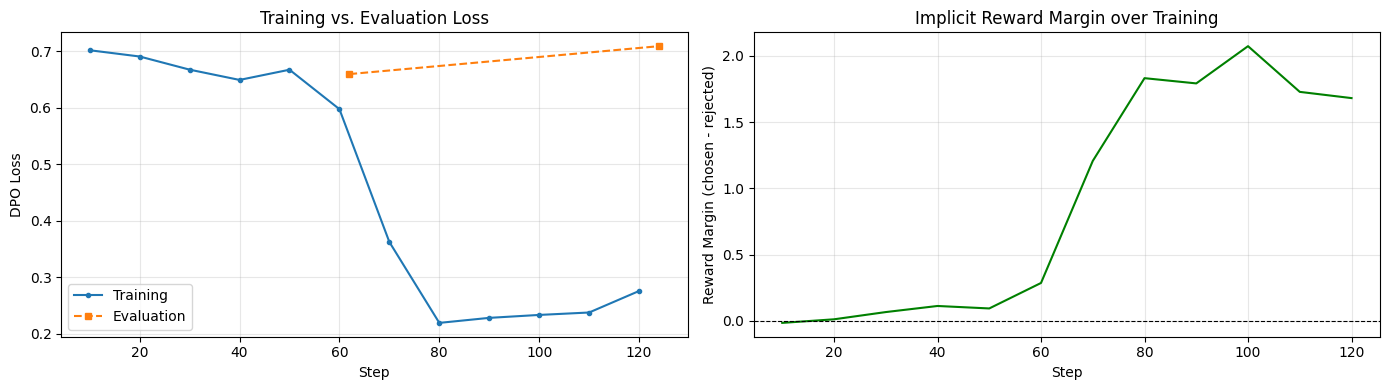

Curves saved to /kaggle/working/dpo_training_curves.png


In [ ]:
log       = pd.DataFrame(trainer.state.log_history)
log_train = log[log["loss"].notna()].copy()
log_eval  = log[log["eval_loss"].notna()].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Loss curves
axes[0].plot(log_train["step"], log_train["loss"],
             label="Training", marker="o", markersize=3, linewidth=1.5)
axes[0].plot(log_eval["step"], log_eval["eval_loss"],
             label="Evaluation", marker="s", markersize=4, linewidth=1.5, linestyle="--")
axes[0].set_xlabel("Step")
axes[0].set_ylabel("DPO Loss")
axes[0].set_title("Training vs. Evaluation Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Reward margins (chosen reward - rejected reward)
if "rewards/chosen" in log.columns and "rewards/rejected" in log.columns:
    log_rewards = log[log["rewards/chosen"].notna()].copy()
    margin = log_rewards["rewards/chosen"] - log_rewards["rewards/rejected"]
    axes[1].plot(log_rewards["step"], margin, color="green", linewidth=1.5)
    axes[1].axhline(0, color="black", linewidth=0.8, linestyle="--")
    axes[1].set_xlabel("Step")
    axes[1].set_ylabel("Reward Margin (chosen - rejected)")
    axes[1].set_title("Implicit Reward Margin over Training")
    axes[1].grid(True, alpha=0.3)
else:
    axes[1].text(0.5, 0.5, "Reward logging not available",
                 ha="center", va="center", transform=axes[1].transAxes)

plt.tight_layout()
plt.savefig("/kaggle/working/dpo_training_curves.png", dpi=150)
plt.show()
print("Curves saved to /kaggle/working/dpo_training_curves.png")

---
## 10) Save Model and Tokenizer

We save **only the LoRA adapter weights** (not the full model). The adapter directory is small (~100–200 MB depending on rank) and contains:
- `adapter_config.json` — LoRA hyperparameters
- `adapter_model.safetensors` — the trained `A` and `B` matrices

The tokenizer is saved alongside so the adapter directory is self-contained for later inference.

In [ ]:
# Save only the LoRA adapter (not the full quantized model)
trainer.model.save_pretrained(ADAPTER_DIR)
tokenizer.save_pretrained(ADAPTER_DIR)

print(f"LoRA adapter saved to : {ADAPTER_DIR}")
print("Contents:")
for f in sorted(os.listdir(ADAPTER_DIR)):
    size = os.path.getsize(os.path.join(ADAPTER_DIR, f))
    print(f"  {f:<40} {size / 1e6:.1f} MB")

LoRA adapter saved to : /kaggle/working/dpo_lora_adapter
Contents:
  README.md                                0.0 MB
  adapter_config.json                      0.0 MB
  adapter_model.safetensors                97.3 MB
  special_tokens_map.json                  0.0 MB
  tokenizer.json                           17.2 MB
  tokenizer_config.json                    0.1 MB


---
## 11) Load Trained LoRA Model




In [ ]:
# ── Step 1: Load the base model fresh (4-bit, no kbit prep, no LoRA) ──────────
# For inference we do not need gradient checkpointing or prepare_model_for_kbit_training.
# We just want the quantized base weights as the backbone.

inference_base = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map="auto",
    trust_remote_code=True,
    torch_dtype=torch.bfloat16,
)
inference_base.config.use_cache = True  # Enable KV cache for faster inference

# ── Step 2: Attach the saved LoRA adapter ─────────────────────────────────────
# PeftModel.from_pretrained reads adapter_config.json from ADAPTER_DIR
# and applies the saved A/B matrices on top of inference_base.

dpo_model = PeftModel.from_pretrained(inference_base, ADAPTER_DIR)
dpo_model.eval()

# ── Reload tokenizer from the adapter directory ───────────────────────────────
# Always reload the tokenizer from the saved adapter dir to guarantee
# that pad_token, special tokens, and chat templates are identical to training.

inference_tokenizer = AutoTokenizer.from_pretrained(ADAPTER_DIR)

print("DPO model loaded via PeftModel.from_pretrained.")
print(f"Tokenizer pad token : {inference_tokenizer.pad_token!r}")

# Confirm the adapter is active
print(f"Active adapters     : {dpo_model.active_adapters}")

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

DPO model loaded via PeftModel.from_pretrained.
Tokenizer pad token : '<|eot_id|>'
Active adapters     : ['default']


---
## 12) Run Inference

We compare the DPO-aligned model against the original LLaMA-3 base to observe the effect of preference fine-tuning.

LLaMA-3 Instruct models use a structured chat template with special tokens:
```
<|begin_of_text|><|start_header_id|>system<|end_header_id|>
{system_message}<|eot_id|>
<|start_header_id|>user<|end_header_id|>
{user_message}<|eot_id|>
<|start_header_id|>assistant<|end_header_id|>
```

We use `tokenizer.apply_chat_template()` to construct this format correctly rather than hard-coding the special tokens.

In [ ]:
# Load the untuned baseline for comparison
base_model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map="auto",
    trust_remote_code=True,
    torch_dtype=torch.bfloat16,
)
base_model.config.use_cache = True
base_model.eval()
print("Baseline model loaded.")

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Baseline model loaded.


In [ ]:
def build_prompt(user_message: str, tokenizer: AutoTokenizer) -> str:
    """
    Format a plain-text user message using LLaMA-3's chat template.
    Returns the tokenizer-ready string.
    """
    messages = [
        {"role": "system",    "content": "You are a helpful, accurate, and concise assistant."},
        {"role": "user",      "content": user_message},
    ]
    # add_generation_prompt=True appends the <|start_header_id|>assistant<|end_header_id|>
    # token sequence so the model knows to start generating the response
    return tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
    )


def generate(
    model: AutoModelForCausalLM,
    tokenizer: AutoTokenizer,
    prompt: str,
    max_new_tokens: int = 256,
    temperature: float = 0.7,
) -> str:
    """
    Run generation and return only the newly generated assistant text,
    with the prompt portion stripped.
    """
    formatted = build_prompt(prompt, tokenizer)
    device    = next(model.parameters()).device
    inputs    = tokenizer(formatted, return_tensors="pt").to(device)
    prompt_len = inputs["input_ids"].shape[-1]

    gen_config = GenerationConfig(
        do_sample=True,
        temperature=temperature,
        top_p=0.9,
        top_k=50,
        max_new_tokens=max_new_tokens,
        repetition_penalty=1.1,
        pad_token_id=tokenizer.pad_token_id,
        eos_token_id=tokenizer.eos_token_id,
    )

    with torch.no_grad():
        output_ids = model.generate(**inputs, generation_config=gen_config)

    # Slice off the prompt tokens; decode only the response
    new_ids = output_ids[0][prompt_len:]
    return tokenizer.decode(new_ids, skip_special_tokens=True).strip()


print("Generation helpers defined.")

Generation helpers defined.


In [ ]:
set_seed(42)

test_prompts = [
    "How can I develop a daily habit of drawing?",
    "Is higher octane gasoline better for your car?",
    "What is the most effective way to learn a new programming language?",
    "How can I improve my sleep quality?",
    "Explain the difference between machine learning and deep learning.",
]

SEP = "=" * 72
print(SEP)
for prompt in test_prompts:
    dpo_response  = generate(dpo_model,  inference_tokenizer, prompt)
    base_response = generate(base_model, inference_tokenizer, prompt)

    print(f"PROMPT         : {prompt}")
    print(f"DPO response   : {dpo_response}")
    print(f"Base response  : {base_response}")
    print(SEP)

PROMPT         : How can I develop a daily habit of drawing?
DPO response   : Developing a daily habit of drawing can be a great way to cultivate your creativity, relax, and express yourself. Here's a step-by-step guide to help you establish a consistent drawing habit:

1. **Set a goal**: Commit to drawing every day for a specific amount of time, e.g., 15-30 minutes. Make it achievable and realistic.
2. **Create a schedule**: Choose a dedicated space and time slot in your daily routine where you'll draw. It could be first thing in the morning, during lunch breaks, or before bed.
3. **Start small**: Begin with short, manageable sessions (10-15 minutes) and gradually increase the duration as you become more comfortable with the habit.
4. **Warm-up exercises**: Begin each session with simple warm-up exercises like gesture drawings, contour drawing, or quick sketches. This will get your creative juices flowing.
5. **Choose a medium**: Select a drawing tool that feels comfortable for you, s

---
## 13) Merge LoRA Weights into the Base Model

For **production deployment**, it is usually preferable to merge the LoRA adapter back into the base model weights.

The merged model:

- **Has no PEFT dependency** at inference time  
- **Runs faster**, since there is no adapter overhead  
- Can be **further quantized or exported**

The method `model.merge_and_unload()` merges the LoRA updates into the original weights:

$$
W_{\text{merged}} = W_{\text{frozen}} + \frac{\alpha}{r} \, B A
$$

This operation is performed for every LoRA-adapted layer and returns a standard **`AutoModelForCausalLM`** without any PEFT wrappers.



In [ ]:
# Merge is optional — set to True to perform it
MERGE_WEIGHTS = True

if MERGE_WEIGHTS:
    print("Reloading base model in fp16 for merging (4-bit cannot be merged in-place)...")

    # Load in fp16 — no quantization
    merge_base = AutoModelForCausalLM.from_pretrained(
        MODEL_ID,
        torch_dtype=torch.float16,
        device_map="auto",
        trust_remote_code=True,
    )

    # Attach the saved LoRA adapter
    merge_model = PeftModel.from_pretrained(merge_base, ADAPTER_DIR)

    # merge_and_unload() folds B @ A into each W_frozen and returns a plain nn.Module
    # with no PEFT wrapper — the result is equivalent to a natively fine-tuned model
    print("Merging LoRA weights into base model...")
    merged_model = merge_model.merge_and_unload()

    # Save the merged model
    merged_model.save_pretrained(MERGED_DIR)
    inference_tokenizer.save_pretrained(MERGED_DIR)

    print(f"Merged model saved to : {MERGED_DIR}")
    print(f"Model class after merge : {type(merged_model).__name__}")

    # Free merge_model from GPU memory
    del merge_base, merge_model
    torch.cuda.empty_cache()
else:
    print("Merge step skipped (MERGE_WEIGHTS = False).")

Reloading base model in fp16 for merging (4-bit cannot be merged in-place)...


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Merging LoRA weights into base model...
Merged model saved to : /kaggle/working/dpo_merged_model
Model class after merge : LlamaForCausalLM


---
## 14)  Gradio Demo

The Gradio interface lets you interactively compare the DPO-aligned model and the base LLaMA-3 side-by-side. Both models receive the same prompt and generation config simultaneously.



The interface exposes:
- A free-text prompt box
- Temperature and max-token sliders
- Side-by-side response panels
- Pre-loaded example prompts

In [ ]:
import gradio as gr
print(f"Gradio version: {gr.__version__}")

Gradio version: 5.50.0


In [ ]:
def run_comparison(
    prompt: str,
    temperature: float,
    max_new_tokens: int,
) -> tuple[str, str]:
    """
    Gradio callback: generate responses from both models and return them
    as a (dpo_response, base_response) tuple.

    Parameters
    ----------
    prompt : str
        Plain-text user instruction.
    temperature : float
        Sampling temperature (0.1 = near-deterministic, 1.5 = highly creative).
    max_new_tokens : int
        Maximum response length in tokens.

    Returns
    -------
    tuple[str, str]
        (DPO model response, Base model response)
    """
    if not prompt.strip():
        return "Please enter a prompt.", "Please enter a prompt."

    dpo_out  = generate(dpo_model,  inference_tokenizer, prompt,
                        max_new_tokens=int(max_new_tokens), temperature=float(temperature))
    base_out = generate(base_model, inference_tokenizer, prompt,
                        max_new_tokens=int(max_new_tokens), temperature=float(temperature))

    return dpo_out, base_out


print("Gradio callback defined.")

Gradio callback defined.


In [ ]:
with gr.Blocks(title="DPO LLaMA-3 vs Base LLaMA-3") as demo:

    gr.Markdown(
        """
        # DPO Fine-Tuned LLaMA-3 vs. LLaMA-3 Baseline

        Compare responses from a **DPO preference-aligned** LLaMA-3 8B model
        against the untuned **base LLaMA-3 8B Instruct** on the same prompt.

        The DPO model was fine-tuned on 1500 samples from `BarraHome/ultrafeedback_binarized`
        using QLoRA (4-bit NF4 + LoRA rank 16) and an explicit frozen reference model.
        """
    )

    with gr.Row():
        with gr.Column(scale=3):
            prompt_box = gr.Textbox(
                label="Prompt",
                placeholder="Enter your question or instruction here...",
                lines=4,
            )
        with gr.Column(scale=1):
            temperature_slider = gr.Slider(
                minimum=0.1, maximum=1.5, value=0.7, step=0.05,
                label="Temperature",
                info="Higher = more creative responses",
            )
            max_tokens_slider = gr.Slider(
                minimum=32, maximum=512, value=256, step=32,
                label="Max New Tokens",
                info="Maximum response length",
            )

    generate_btn = gr.Button("Generate", variant="primary", size="lg")

    with gr.Row():
        dpo_output = gr.Textbox(
            label="DPO Fine-Tuned LLaMA-3",
            lines=12, interactive=False,
        )
        base_output = gr.Textbox(
            label="LLaMA-3 Base (No DPO)",
            lines=12, interactive=False,
        )

    gr.Examples(
        label="Example Prompts",
        examples=[
            ["How can I develop a daily habit of drawing?",                   0.7, 256],
            ["Is higher octane gasoline better for your car?",                0.5, 200],
            ["What is the most effective way to learn a new language?",       0.7, 256],
            ["Explain quantum computing to a ten-year-old.",                  0.8, 300],
            ["What are the pros and cons of working from home?",              0.7, 256],
            ["How can I improve my sleep quality?",                           0.6, 200],
            ["Explain the difference between machine learning and deep learning.", 0.7, 256],
        ],
        inputs=[prompt_box, temperature_slider, max_tokens_slider],
    )

    # Wire button and Enter key to the same callback
    generate_btn.click(
        fn=run_comparison,
        inputs=[prompt_box, temperature_slider, max_tokens_slider],
        outputs=[dpo_output, base_output],
    )
    prompt_box.submit(
        fn=run_comparison,
        inputs=[prompt_box, temperature_slider, max_tokens_slider],
        outputs=[dpo_output, base_output],
    )

# share=True creates a public tunnel URL (requires internet enabled in Kaggle settings)
demo.launch(share=True, debug=False)
print("Gradio interface launched. Use the public URL printed above.")

* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://9a888a824500b85047.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Gradio interface launched. Use the public URL printed above.
